In [4]:
# !pip install surprise
import surprise
print(surprise.__version__)

1.1.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

mpl.rc('font', family='NanumGothic') # 폰트 설정
mpl.rc('axes', unicode_minus=False) # 유니코드에서 음수 부호 설정

# 차트 스타일 설정
sns.set( rc={"axes.unicode_minus":False}, style='darkgrid')
plt.rc("figure", figsize=(10,8))

%cd /content/drive/MyDrive/AI응용_팀플_Lpoint

/content/drive/MyDrive/AI응용_팀플_Lpoint


### 데이터 로드

What is RFM analysis?           
RFM stands for recency, frequency, monetary value. In business analytics, we often use this concept to divide customers into different segments, like high-value customers, medium value customers or low-value customers, and similarly many others.

Let’s assume we are a company, our company name is geek, let’s perform the RFM analysis on our customers

Recency: How recently has the customer made a transaction with us
Frequency: How frequent is the customer in ordering/buying some product from us
Monetary: How much does the customer spend on purchasing products from us.

In [8]:
# df = pd.read_csv('./data/fin_data_set.csv')
df1 = pd.read_csv('./data/final_data.csv')
# age_cluster = pd.read_csv('./age_cluster.csv')
# fre_cluster = pd.read_csv('./fre_cluster.csv')

In [9]:
df1.head(2)

,cno,gender,age_grp,scls_c_nm,Recency,Frequency,Monetory
0,1,M,60세이상,Bag&Bag,135,1,186200
1,1,M,60세이상,L.B,277,1,85500


In [11]:
data = df1[['cno','gender','age_grp']].drop_duplicates()
data.groupby(['age_grp'])['cno'].count()

age_grp
19세이하        14
20세~24세     258
25세~29세     642
30세~34세    1590
35세~39세    2564
40세~44세    3347
45세~49세    3762
50세~54세    2894
55세~59세    1661
60세이상      1221
Name: cno, dtype: int64

In [ ]:
# Calculating Recency
# Here we are calculating recency for customers who had made a purchase with a company.
# df_recency = df.groupby(by='Customer Name',
#                         as_index=False)['Order Date'].max()
# df_recency.columns = ['CustomerName', 'LastPurchaseDate']
# recent_date = df_recency['LastPurchaseDate'].max()
# df_recency['Recency'] = df_recency['LastPurchaseDate'].apply(
#     lambda x: (recent_date - x).days)
# df_recency.head()

# Calculating Frequency
# We are here calculating the frequency of frequent transactions of the customer in ordering/buying some product from the company.

# frequency_df = df.drop_duplicates().groupby(
#     by=['Customer Name'], as_index=False)['Order Date'].count()
# frequency_df.columns = ['CustomerName', 'Frequency']
# frequency_df.head()


# Calculating Monetary Value
# Here we are calculating the monetary value of customer spend on purchasing products from the company.
# df['Total'] = df['Sales']*df['Quantity']
# monetary_df = df.groupby(by='Customer Name', as_index=False)['Total'].sum()
# monetary_df.columns = ['CustomerName', 'Monetary']
# monetary_df.head()

# Merging all three columns in one dataframe
# Here we are merging all the dataframe columns in a single entity using the merge function to display the recency, frequency, monetary value.
# rf_df = df_recency.merge(frequency_df, on='CustomerName')
# rfm_df = rf_df.merge(monetary_df, on='CustomerName').drop(
#     columns='LastPurchaseDate')
# rfm_df.head()

In [37]:
# 아이템 RFM 점수내기
df1.head()

,cno,gender,age_grp,scls_c_nm,Recency,Frequency,Monetory,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score
0,1,M,60세이상,Bag&Bag,135,1,186200,44.510662,21.107665,72.703466,2.701386
1,1,M,60세이상,L.B,277,1,85500,13.718939,21.107665,55.403240,1.977392
2,1,M,60세이상,L/C 아웃도어,186,1,90250,31.982380,21.107665,56.860083,2.155888
3,1,M,60세이상,N.B,227,1,251750,22.979643,21.107665,78.315349,2.699842
4,1,M,60세이상,global SPA,310,2,54800,8.770172,51.462927,44.587151,2.056991


In [39]:
Recency_df1 = df1.groupby(
    by=['scls_c_nm'], as_index=False)['Recency'].sum()
Recency_df1.columns = ['scls_c_nm', 'Recency']

Frequency_df1 = df1.groupby(
    by=['scls_c_nm'], as_index=False)['Frequency'].sum()
Frequency_df1.columns = ['scls_c_nm', 'Frequency']

Monetory_df1 = df1.groupby(
    by=['scls_c_nm'], as_index=False)['Monetory'].sum()
Monetory_df1.columns = ['scls_c_nm', 'Monetory']

In [40]:
item_df = Recency_df1.merge(Frequency_df1, on='scls_c_nm')
item_df = item_df.merge(Monetory_df1, on='scls_c_nm')
item_df.head()

,scls_c_nm,Recency,Frequency,Monetory
0,14K,285725,3827,751819140
1,4대 B/D,400661,4164,1297063360
2,5 ON THE GO,5706,43,8061040
3,ACC Bloom (1F),2106,52,1212300
4,ACC Bloom (3F),83207,909,34501580


In [ ]:
df.head()  #user

,customer,Recency,Frequency,Monetory,Purchase_Cycle
0,1,11.0,322,35834150,3.76
1,2,3.0,319,51600290,2.78
2,4,1.0,227,5828650,3.50
3,5,1.0,103,4022940,5.52
4,6,2.0,170,8297060,3.19


In [14]:
df1.head()    #scls_c_nm

,cno,gender,age_grp,scls_c_nm,Recency,Frequency,Monetory
0,1,M,60세이상,Bag&Bag,135,1,186200
1,1,M,60세이상,L.B,277,1,85500
2,1,M,60세이상,L/C 아웃도어,186,1,90250
3,1,M,60세이상,N.B,227,1,251750
4,1,M,60세이상,global SPA,310,2,54800


### RFM analysis

In [20]:
def rmf_score(df, cus):  
  df['R_rank'] = df['Recency'].rank(ascending=False)
  df['F_rank'] = df['Frequency'].rank(ascending=True)
  df['M_rank'] = df['Monetory'].rank(ascending=True)
  # normalizing the rank of the customers
  df['R_rank_norm'] = (df['R_rank']/df['R_rank'].max())*100
  df['F_rank_norm'] = (df['F_rank']/df['F_rank'].max())*100
  df['M_rank_norm'] = (df['M_rank']/df['M_rank'].max())*100
  df.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)

  # Calculating RFM score
  # RFM score is calculated based upon recency, frequency, monetary value normalize ranks. 
  # Based upon this score we divide our customers. Here we rate them on a scale of 5. 
  # Formula used for calculating rfm score is : 0.15*Recency score + 0.28*Frequency score + 0.57 *Monetary score

  df['RFM_Score'] = 0.15*df['R_rank_norm']+0.28 * \
      df['F_rank_norm']+0.57*df['M_rank_norm']
  df['RFM_Score'] *= 0.05
  df = df.round(2)
  print(df[[f'{cus}', 'RFM_Score']].head(3))
  return df

In [19]:
# Rating Customer based upon the RFM score
# rfm score >4.5 : Top Customer
# 4.5 > rfm score > 4 : High Value Customer
# 4>rfm score >3 : Medium value customer
# 3>rfm score>1.6 : Low-value customer
# rfm score<1.6 :Lost Customer
def Rating_cust(df,cus):
  df["Customer_segment"] = np.where(df['RFM_Score'] >
                                        4.5, "Top Customers",
                                        (np.where(
                                          df['RFM_Score'] > 4,
                                          "High value Customer",
                                          (np.where(
      df['RFM_Score'] > 3,
                              "Medium Value Customer",
                              np.where(df['RFM_Score'] > 1.6,
                              'Low Value Customers', 'Lost Customers'))))))
  print(df[[f'{cus}', 'RFM_Score', 'Customer_segment']].head(5))
  return df

In [42]:
item_rfm1 = rmf_score(item_df,'scls_c_nm')
item_rfm1 = Rating_cust(item_rfm1,'scls_c_nm')

     scls_c_nm  RFM_Score
0          14K       3.69
1       4대 B/D       3.81
2  5 ON THE GO       1.51
        scls_c_nm  RFM_Score       Customer_segment
0             14K       3.69  Medium Value Customer
1          4대 B/D       3.81  Medium Value Customer
2     5 ON THE GO       1.51         Lost Customers
3  ACC Bloom (1F)       1.18         Lost Customers
4  ACC Bloom (3F)       2.36    Low Value Customers


In [6]:
# user_rfm.to_csv('./rfm_score.csv')
# item_rfm.to_csv('./rfm_score1.csv')
# item_rfm1.to_csv('./rfm_score2.csv')   <  아이템 점수
user_rfm = pd.read_csv('./rfm_score.csv', index_col = False)
item_rfm = pd.read_csv('./rfm_score1.csv', index_col = False)
item_score = pd.read_csv('./rfm_score2.csv', index_col = False)

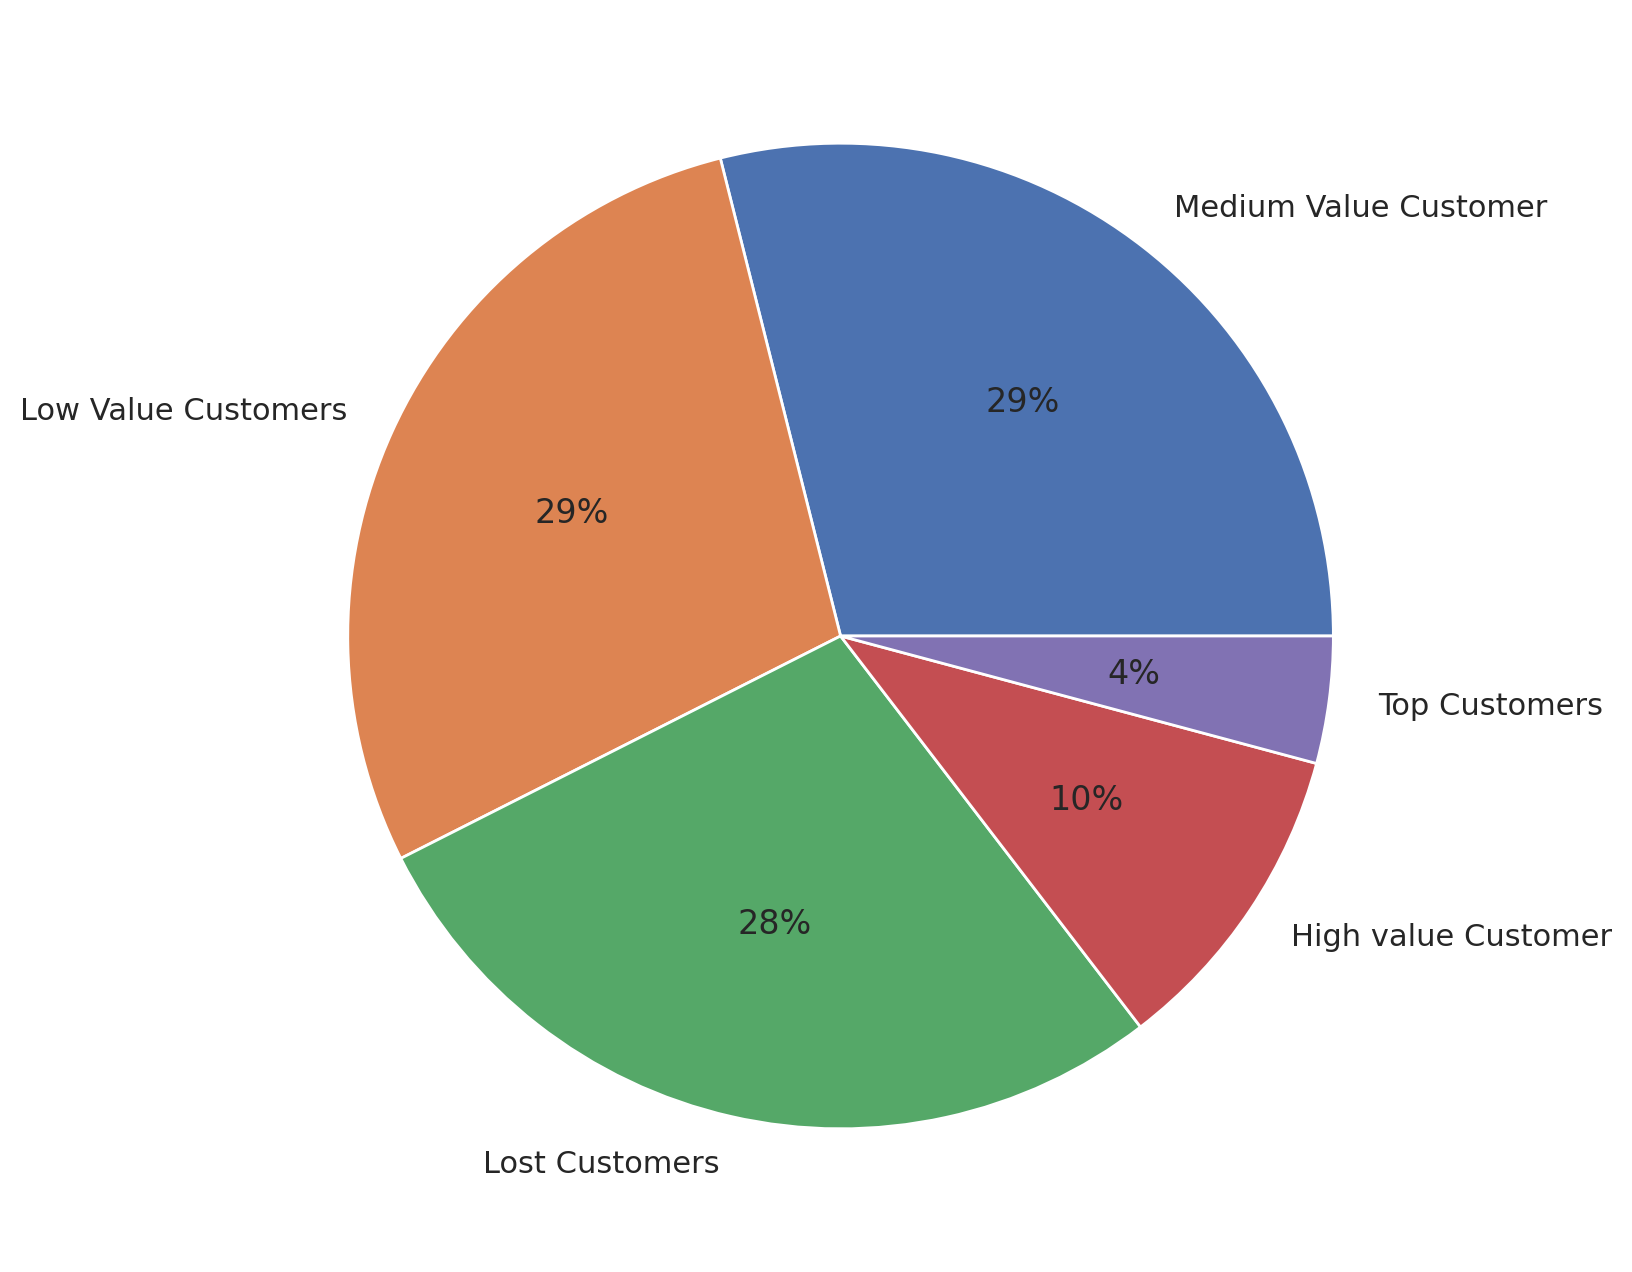

In [25]:
# Visualizing the customer segments
# Here we will use a pie plot to display all segments of customers.

plt.pie(user_rfm.Customer_segment.value_counts(),
        labels=user_rfm.Customer_segment.value_counts().index,
        autopct='%.0f%%')
plt.show()

### RFM score 이용하여 사용자기반, 아이템기반 구현


In [48]:
# 사용자점수
user_rfm.head(2)

,Unnamed: 0,customer,Recency,Frequency,Monetory,Purchase_Cycle,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,0,1,11.0,322,35834150,3.76,27.27,87.68,81.67,3.76,Medium Value Customer
1,1,2,3.0,319,51600290,2.78,58.77,86.84,90.29,4.23,High value Customer


In [47]:
# 아이템점수
item_rfm.head(2)

,Unnamed: 0,cno,gender,age_grp,scls_c_nm,Recency,Frequency,Monetory,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,0,1,M,60세이상,Bag&Bag,135,1,186200,44.51,21.11,72.7,2.70,Low Value Customers
1,1,1,M,60세이상,L.B,277,1,85500,13.72,21.11,55.4,1.98,Low Value Customers


In [46]:
item_rfm1.head(2)

,scls_c_nm,Recency,Frequency,Monetory,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,14K,285725,3827,751819140,22.73,75.76,86.20,3.69,Medium Value Customer
1,4대 B/D,400661,4164,1297063360,16.84,77.10,91.25,3.81,Medium Value Customer


In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.metrics.pairwise import cosine_similarity
import operator
%matplotlib inline

In [8]:
# 사용자 > 아이템 score
rating = item_rfm[['cno','scls_c_nm','RFM_Score']]
rating.head(2)

,cno,scls_c_nm,RFM_Score
0,1,Bag&Bag,2.70
1,1,L.B,1.98


In [50]:
# 아이템 평균 score
item = item_rfm1[['scls_c_nm','RFM_Score']]
item.head(2)

,scls_c_nm,RFM_Score
0,14K,3.69
1,4대 B/D,3.81


In [51]:
# Join the two dataframes on the scls_c_nm columns
merged = rating.merge(item, left_on = 'scls_c_nm', right_on = 'scls_c_nm', suffixes= ['_user', ''])
merged.rename(columns = {'RFM_Score_user':'user_rating'}, inplace = True)

In [53]:
merged.shape

(723242, 4)

In [58]:
merged.head()

,cno,scls_c_nm,user_rating,RFM_Score
0,1,Bag&Bag,2.70,2.81
1,74,Bag&Bag,2.51,2.81
2,84,Bag&Bag,1.23,2.81
3,99,Bag&Bag,1.89,2.81
4,177,Bag&Bag,1.39,2.81


In [59]:
# User CF - row : 사용자 , column : 아이템, values : 평가점수
# Item CF - row : 아이템 , column : 사용자, values : 평가점수
piv = merged.pivot_table(index=['cno'], columns=['scls_c_nm'], values='user_rating')

In [60]:
print(piv.shape)
piv.head()

(17953, 594)


scls_c_nm,14K,4대 B/D,5 ON THE GO,ACC Bloom (1F),ACC Bloom (3F),AK골프,ANDZ,ARCHIV,BON,Bag&Bag,...,화과자,화장품,회,휘트니스,휠라골프,휠라아웃도어,휴고보스,휴고보스골프,휴지류,힐앤토트
cno,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
# 사용자 개개인의 평가 척도를 조정해주기 위해 표준화 작업을 진행
# Normalize the values
piv_norm = piv.apply(lambda x: (x-np.mean(x))/(np.max(x)-np.min(x)), axis=1) # min-max scaling 

# Null 값을 0으로 대체
# Drop all columns containing only zeros representing users who did not rate
piv_norm.fillna(0, inplace=True)
piv_norm = piv_norm.T
piv_norm = piv_norm.loc[:, (piv_norm != 0).any(axis=0)]


# 유사도 계산, scipy의 csr_matrix
# Our data needs to be in a sparse matrix format to be read by the following functions
piv_sparse = sp.sparse.csr_matrix(piv_norm.values)

In [63]:
item_similarity = cosine_similarity(piv_sparse)
user_similarity = cosine_similarity(piv_sparse.T)  # 전치

In [64]:
# Inserting the similarity matricies into dataframe objects
item_sim_df = pd.DataFrame(item_similarity, index = piv_norm.index, columns = piv_norm.index)
user_sim_df = pd.DataFrame(user_similarity, index = piv_norm.columns, columns = piv_norm.columns)

In [67]:
# This function will return the top 10 shows with the highest cosine similarity value
def top_item(item_nm):
    count = 1
    print('Similar shows to {} include:\n'.format(item_nm))
    result = item_sim_df.loc[~item_sim_df.index.isin([item_nm]), item_nm].sort_values(ascending = False)[:10]
    for item, score in result.items():
        print('No. {}: {}({:.2f})'.format(count, item , score))
        count +=1  

In [68]:
# This function will return the top 5 users with the highest similarity value 
def top_users(user):
    if user not in piv_norm.columns:
        return('No data available on user {}'.format(user))

    print('Most Similar Users:\n')
    result = user_sim_df.sort_values(by=user, ascending=False).loc[:,user][1:11]
    for user, sim in result.items():
        print('User #{0}, Similarity value: {1:.2f}'.format(user, sim)) 

In [69]:
top_item('화과자')

Similar shows to 화과자 include:

No. 1: 특산물행사(0.17)
No. 2: 햄(0.17)
No. 3: 일용잡화(0.17)
No. 4: 중식델리(0.16)
No. 5: 냉동식품(0.15)
No. 6: 떡(0.15)
No. 7: 김류(0.14)
No. 8: 아이스크림(0.14)
No. 9: 어묵(0.13)
No. 10: 멸치류(0.13)


In [72]:
top_users(214)

Most Similar Users:

User #3011, Similarity value: 0.46
User #9390, Similarity value: 0.42
User #4575, Similarity value: 0.41
User #2320, Similarity value: 0.41
User #238, Similarity value: 0.41
User #18972, Similarity value: 0.40
User #878, Similarity value: 0.40
User #3797, Similarity value: 0.40
User #636, Similarity value: 0.40
User #14171, Similarity value: 0.39


In [ ]:
# 구매 top 10


### User-based CF는 비슷한 회원들과 유사도 점수를 나타내주지만 보통 추천 서비스에서는 아이템 list를 추천

In [73]:
# 지정 사용자의 유사도가 높은 10명의 비슷한 사용자를 기준으로 item을 추천해주는 함수
# This function constructs a list of lists containing the highest rated shows per similar user
# and returns the name of the show along with the frequency it appears in the list

def similar_user_recs(user):
    if user not in piv_norm.columns:
        return('No data available on user {}'.format(user))

    # 유사도가 높은 10명의 사용자를 가져옵니다. 
    sim_users = user_sim_df.sort_values(by=user, ascending=False).index[1:11] 
    best = []
    most_common = {}


    for i in sim_users:
        # 유사도가 높은 10명의 사용자들이 평가점수를 높게 주었던 item list를 가져옵니다. 
        # 단, 주의해야할 점은 추천하려고 하는 대상 user가 평가하지 않았던 아이템이어야 합니다. 
        result_sorted = piv_norm.loc[:, i][(piv_norm.loc[:,user] == 0)].sort_values(ascending = False)
        best.append(result_sorted.index[:5].tolist())
#     print(best)
    for i in range(len(best)):
        for j in best[i]:
            if j in most_common:
                most_common[j] += 1
            else:
                most_common[j] = 1
    sorted_list = sorted(most_common.items(), key=operator.itemgetter(1), reverse=True)
    return sorted_list[:5]   

In [74]:
df1['cno'].sample(n=1)

607846    14769
Name: cno, dtype: int64

In [75]:
similar_user_recs(14769)

[('란제리', 3), ('브랜드샵', 2), ('캐릭터 여화', 2), ('올리브핫스텁', 2), ('L/C 아동복', 2)]

### SVD 추천엔진


In [2]:
# item_rfm.head(2)
import pandas as pd
item_rfm = pd.read_pickle('./data/item_rfm.pkl')
ratings = item_rfm[['cno','scls_c_nm','RFM_Score']]
itemRatings = ratings.pivot_table(index=['cno'],columns=['scls_c_nm'],values='RFM_Score')
itemRatings.head(2)

scls_c_nm,14K,4대 B/D,5 ON THE GO,ACC Bloom (1F),ACC Bloom (3F),AK골프,ANDZ,ARCHIV,BON,Bag&Bag,...,화과자,화장품,회,휘트니스,휠라골프,휠라아웃도어,휴고보스,휴고보스골프,휴지류,힐앤토트
cno,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
item_score = pd.read_pickle('./data/item_score.pkl')
items = item_score[['scls_c_nm','RFM_Score']]
item_ratings = pd.merge(items, ratings, left_on='scls_c_nm', right_on='scls_c_nm')

In [4]:
item_ratings.head(2)

,scls_c_nm,RFM_Score_x,cno,RFM_Score_y
0,14K,3.69,20,2.64
1,14K,3.69,35,4.48


In [ ]:
!pip install scikit-surprise

In [ ]:
from surprise import Dataset
from surprise import Reader
from collections import defaultdict

reader = Reader(rating_scale=(ratings['RFM_Score'].min(), ratings['RFM_Score'].max())) 
data = Dataset.load_from_df(ratings[['cno', 'scls_c_nm', 'RFM_Score']],reader) 

In [19]:
from surprise import SVD
from surprise import NormalPredictor
from surprise.model_selection import GridSearchCV

# 하이퍼 파라미터 그리드 검색을 해서 최적의 파라미터를 찾는다
# scikit-learn의 GridSearchCV와 아주 흡사
# - n_factors: 축소 차원수 (앞 그림에서 시그마 행렬의 차원수 - r)
# - n_epochs: 전체 데이터 셋을 훈련시키는 횟수
# - lr_all: 학습률 

param_grid = {
  'n_epochs': [20, 30],
  'lr_all': [0.005, 0.010],            
  'n_factors': [50, 100]
}

# 3-폴드 교차검증을 하고 두 개의 비용함수를 사용: RMSE와 MAE (Mean Absolute Error)
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

In [20]:
# RMSE
print("Best RMSE score attained: ", gs.best_score['rmse'])
print("Best RMSE params: ", gs.best_params['rmse'])

# MAE
print("Best RAE score attained: ", gs.best_score['mae'])
print("Best RAE params: ", gs.best_params['mae'])

Best RMSE score attained:  1.0109093272551652
Best RMSE params:  {'n_epochs': 30, 'lr_all': 0.005, 'n_factors': 100}
Best RAE score attained:  0.8281510410224207
Best RAE params:  {'n_epochs': 30, 'lr_all': 0.005, 'n_factors': 100}


In [21]:
svd = gs.best_estimator['rmse']
trainset = data.build_full_trainset()
svd.fit(trainset)

In [22]:
ratings.sample(n=2)

,cno,scls_c_nm,RFM_Score
271269,5602,식당가 커피숍,0.85
71816,1343,선글라스(특정),3.63


In [23]:
uid = str(5602)  # raw user id (as in the ratings file). They are **strings**!
iid = str('선글라스(특정)')  # raw item nm (as in the ratings file). They are **strings**!

# get a prediction for specific users and items.
pred = svd.predict(uid, iid, verbose=True)   # r_ui=4,

user: 5602       item: 선글라스(특정)   r_ui = None   est = 2.68   {'was_impossible': False}


In [24]:
# Train/Test Split로 훈련하고 성능 평가해보기

from surprise import accuracy
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=.25)

svd = SVD()
svd.fit(trainset)
predictions = svd.test(testset)

# Then compute RMSE
accuracy.rmse(predictions)
testset[0:10]

RMSE: 1.0094


[(5988, '떡', 1.75),
 (7823, '색조 화장품', 3.84),
 (14612, '양말(특정)', 0.86),
 (11828, '에스프레소', 3.79),
 (13026, '일꼬르소', 3.29),
 (9151, '골프용품', 1.45),
 (12804, '분식', 3.65),
 (5028, '중식델리', 3.26),
 (17447, '스타킹(특정)', 1.27),
 (17127, '유기농채소', 2.43)]

In [28]:
pred = svd.predict("17127", "분식", verbose=True)

user: 17127      item: 분식         r_ui = None   est = 1.93   {'was_impossible': False}


In [29]:
# top-N 정확도 계산
# 사용자별로 10개의 추천 아이템을 생성
# 인자인 predictions로는 SVD의 test의 리턴값을 사용
def get_top_n(predictions, n=10):

    top_n = defaultdict(list)

    # predictions의 각 레코드는 (사용자 ID, 아이템 ID, 실제 평점, 예측 평점)으로 구성
    for uid, iid, true_r, est, _ in predictions:
        # 사용자별로 영화ID와 예측 평점을 같이 저장
        top_n[uid].append((iid, est))
 
    # 위에서 채워진 top_n을 사용자ID를 가지고 예측평점이 높은 n개의 영화로 교체
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
 
    return top_n

In [30]:
from surprise.model_selection import LeaveOneOut

# 각 사용자별로 하나의 평점만을 테스트셋에 보관 (n_splits가 1 즉 1개의 폴드)
LOOCV = LeaveOneOut(n_splits=1, random_state=1)
ratingCutoff = 4.0

for trainSet, testSet in LOOCV.split(data):
  pass

len(testSet)

17953

In [31]:
# 훈련 데이터셋으로 학습 
svd.fit(trainSet)


# 훈련 데이터셋에 있지 않은 모든 데이터를 테스트셋으로 리턴
bigTestSet = trainSet.build_anti_testset()

print(len(bigTestSet))

9161051


In [32]:
# 위에서 리턴된 데이터에 대해 평점 예측
allPredictions = svd.test(bigTestSet)

# 각 사용자별로 아직 보지 못한 영화들을 대상으로 top 20 평점 영화 리스트를 추출
topNPredicted = get_top_n(allPredictions, n=20)

# 예를 들어 사용자 '1'의 추천 리스트를 확인
for tnp in topNPredicted['1']:
  # tnp는 tuple로 영화ID와 평점으로 구성
  print(tnp)

In [34]:
# top N 정확도를 계산
hits = 0
total = 0

# 남겨졌던 데이터의 사용자들을 대상으로 cutoffRating이상의 평점을 갖는 아이템이 추천되었는지 확인
for userID, leftOutMovieID, trueRating in testSet:
    # print(userID, leftOutMovieID, trueRating)
    # 높은 평점이 매칭되는 경우만 고려
    if (trueRating >= ratingCutoff):         
        # 사용자의 추천 리스트를 확인   
        for movieID, predictedRating in topNPredicted[userID]:
            # 해당 사용자의 추천 아이템에 해당 영화가 존재하는 경우에만 카운트
            if (leftOutMovieID == movieID):
                hits += 1
                break
        total += 1

print(hits/float(total)*100.)

24.761146496815286
